In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, ConfusionMatrixDisplay, classification_report

In [2]:
RANDOM_STATE = 0
PATH = "dataset.csv"
POPULAR_THRESHOLD = 70

feat_cols = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", 
    "valence", "tempo", "duration_ms", "key", "mode", "time_signature", "explicit"]

In [3]:
df = pd.read_csv(PATH)

popularity_scores = df["popularity"]
is_popular = popularity_scores >= POPULAR_THRESHOLD
df["label_popular"] = is_popular

feat_table = df[feat_cols]

feat_medians = feat_table.median()
new_feat = feat_table.fillna(feat_medians)

X = new_feat.to_numpy()
y = df["label_popular"].to_numpy()

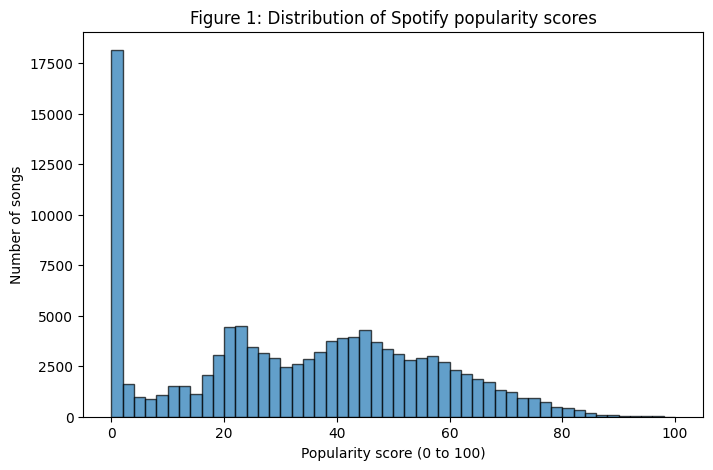

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df["popularity"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Popularity score (0 to 100)")
plt.ylabel("Number of songs")
plt.title("Figure 1: Distribution of Spotify popularity scores")
plt.show()

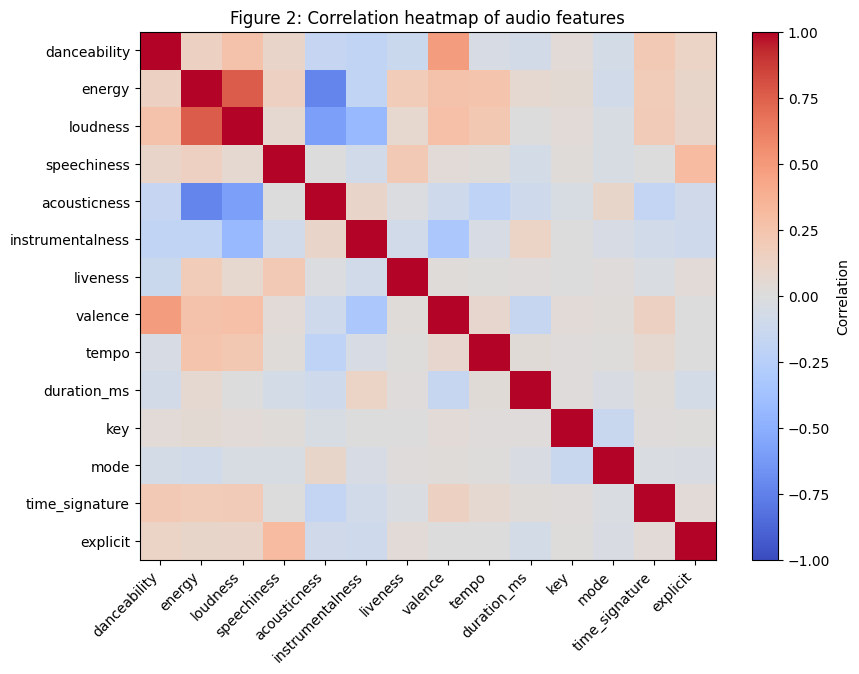

In [5]:
correlation_matrix = df[feat_cols].corr()
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
tick_positions = list(range(len(feat_cols)))
plt.xticks(tick_positions, feat_cols, rotation=45, ha="right")
plt.yticks(tick_positions, feat_cols)
plt.title("Figure 2: Correlation heatmap of audio features")
plt.subplots_adjust(bottom=0.22, left=0.18)
plt.show()


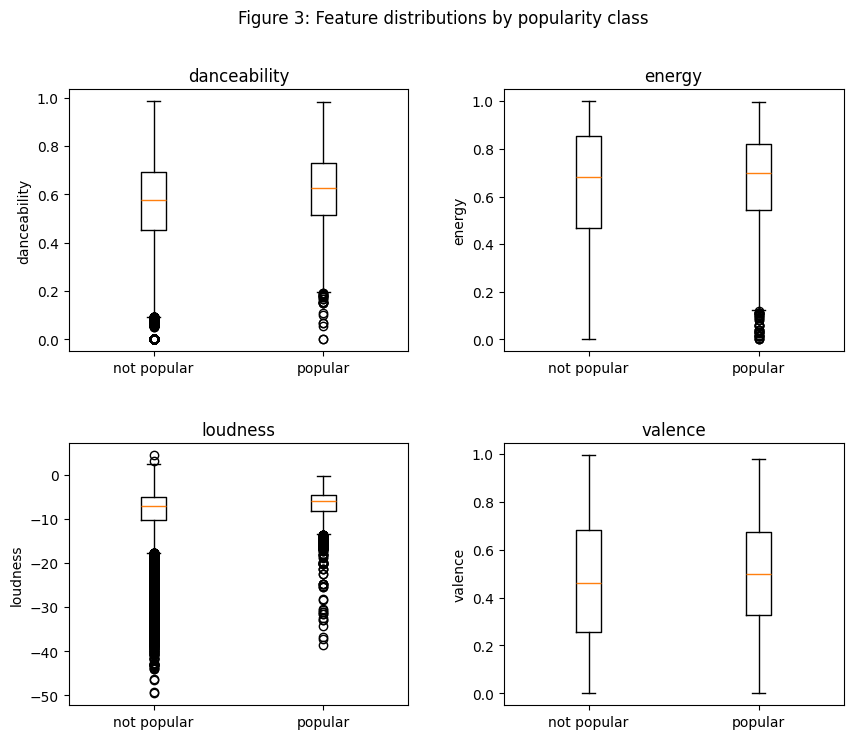

In [6]:

boxplot_features = ["danceability", "energy", "loudness", "valence"]
figure_box, axes_grid = plt.subplots(2, 2, figsize=(10, 8))
axes_list = [axes_grid[0, 0], axes_grid[0, 1], axes_grid[1, 0], axes_grid[1, 1]]
for plot_index in range(len(boxplot_features)):
    feature_name = boxplot_features[plot_index]
    current_axis = axes_list[plot_index]
    values_not_popular = df.loc[df["label_popular"] == False, feature_name].dropna()
    values_popular = df.loc[df["label_popular"] == True, feature_name].dropna()
    current_axis.boxplot(
        [values_not_popular, values_popular],
        tick_labels=["not popular", "popular"],
    )
    current_axis.set_title(feature_name)
    current_axis.set_ylabel(feature_name)
figure_box.suptitle("Figure 3: Feature distributions by popularity class")
plt.subplots_adjust(top=0.88, hspace=0.35, wspace=0.28)
plt.show()

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_size = X_train_scaled.shape[0]
test_size = X_test_scaled.shape[0]
print("Train size: " + str(train_size))
print("Test size: " + str(test_size))

Train size: 91200
Test size: 22800


In [8]:
logistic_regression_model = LogisticRegression(max_iter=3000, class_weight="balanced")

logistic_regression_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [9]:
threshold = 0.5
probability_matrix = logistic_regression_model.predict_proba(X_test_scaled)
test_popular_proba = probability_matrix[:, 1]
y_test_pred = test_popular_proba >= threshold

In [10]:
accuracy = accuracy_score(y_test, y_test_pred)
error = 1.0 - accuracy
precision = precision_score(y_test, y_test_pred, pos_label=True)
recall = recall_score(y_test, y_test_pred, pos_label=True)
f1_metric = f1_score(y_test, y_test_pred, pos_label=True)
roc_auc = roc_auc_score(y_test, test_popular_proba)
confusion = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(confusion)
print("")
print("Threshold: " + str(threshold))
print("Accuracy: " + str(accuracy))
print("Error: " + str(error))
print("Precision: " + str(precision))
print("Recall: " + str(recall))
print("F1 score: " + str(f1_metric))
print("ROC-AUC: " + str(roc_auc))

print("")
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=["not_popular", "popular"]))

roc_false_positive_rate, roc_true_positive_rate, roc_threshold_values = roc_curve(
    y_test, test_popular_proba
)

Confusion matrix:
[[12255  9451]
 [  305   789]]

Threshold: 0.5
Accuracy: 0.5721052631578948
Error: 0.4278947368421052
Precision: 0.07705078125
Recall: 0.7212065813528337
F1 score: 0.13922710428798307
ROC-AUC: 0.7004320324576848

Classification report:
              precision    recall  f1-score   support

 not_popular       0.98      0.56      0.72     21706
     popular       0.08      0.72      0.14      1094

    accuracy                           0.57     22800
   macro avg       0.53      0.64      0.43     22800
weighted avg       0.93      0.57      0.69     22800



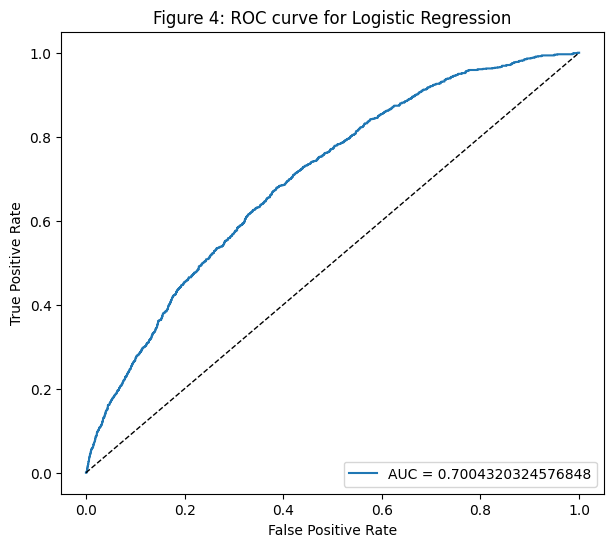

In [11]:
plt.figure(figsize=(7, 6))
auc_label = "AUC = " + str(roc_auc)
plt.plot(roc_false_positive_rate, roc_true_positive_rate, label=auc_label)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 4: ROC curve for Logistic Regression")
plt.legend(loc="lower right")
plt.show()

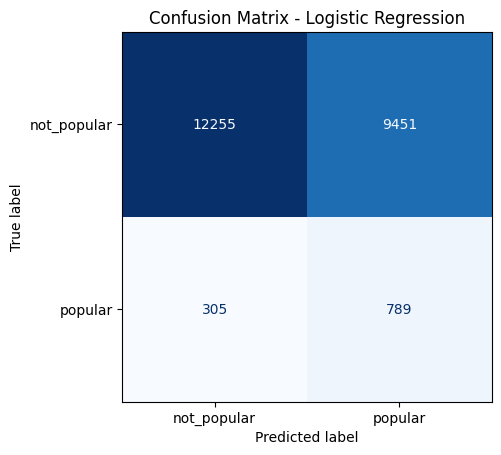

In [12]:
confusion_matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["not_popular", "popular"],
)
confusion_matrix_display.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [13]:
model_coefficients = logistic_regression_model.coef_[0]
coefficients_df = pd.DataFrame({"feature": feat_cols, "coef": model_coefficients})
coefficients_df["abs_coef"] = np.abs(coefficients_df["coef"])

pos_rows = []
neg_rows = []
pos_count = 0
neg_count = 0
for i in range(len(coefficients_df)):
    row = coefficients_df.iloc[i]
    coef_value = row["coef"]
    if coef_value > 0:
        pos_rows.append(row)
        pos_count = pos_count + 1
    if coef_value < 0:
        neg_rows.append(row)
        neg_count = neg_count + 1

pos_df = pd.DataFrame(pos_rows).sort_values("abs_coef", ascending=False)
neg_df = pd.DataFrame(neg_rows).sort_values("abs_coef", ascending=False)

print("")
print(
    "There are "
    + str(pos_count)
    + " features with positive coefficients (they increase predicted probability of popular)."
)
print(
    "There are "
    + str(neg_count)
    + " features with negative coefficients (they decrease predicted probability of popular)."
)
print("")
print("Top five features by absolute positive coefficient (strength toward popular):")
print(pos_df.head(5)[["feature", "coef"]].to_string(index=False))

print("")
print("Top five features by absolute negative coefficient (strength away from popular):")
print(neg_df.head(5)[["feature", "coef"]].to_string(index=False))

print("")
print("All coefficients, sorted from largest to smallest:")
coefficients_sorted = coefficients_df.sort_values("coef", ascending=False)
coefficients_table = coefficients_sorted[["feature", "coef"]]
print(coefficients_table)



There are 5 features with positive coefficients (they increase predicted probability of popular).
There are 9 features with negative coefficients (they decrease predicted probability of popular).

Top five features by absolute positive coefficient (strength toward popular):
       feature     coef
      loudness 0.427603
      explicit 0.179127
  danceability 0.167943
time_signature 0.021201
           key 0.007137

Top five features by absolute negative coefficient (strength away from popular):
         feature      coef
instrumentalness -0.639689
    acousticness -0.420289
          energy -0.382677
        liveness -0.316805
     speechiness -0.250208

All coefficients, sorted from largest to smallest:
             feature      coef
2           loudness  0.427603
13          explicit  0.179127
0       danceability  0.167943
12    time_signature  0.021201
10               key  0.007137
11              mode -0.037479
7            valence -0.072004
9        duration_ms -0.084870
8    